# Multi-Layer Perceptron (MLP) Neural Network

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv('preprocessed_loan_data.csv')

data.head()

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,person_age,credit_score,person_emp_exp,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender,previous_loan_defaults_on_file,loan_status
0,1.000000,0.715620,0.087589,0.14898,0.250733,0.000000,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
1,0.175824,0.401104,0.014596,0.10092,0.058291,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,1
2,0.967033,0.512603,0.087589,0.29316,0.500570,0.162162,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
3,0.967033,0.664705,0.014596,0.19704,0.635617,0.000000,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
4,1.000000,0.602833,0.160582,0.24510,0.335137,0.054054,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0


# Split the data

In [3]:
# Separate feature columns and target column
X = data.drop('loan_status', axis=1)   # All columns except the target
Y = data['loan_status']                # Target column

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

In [5]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (56000, 23)
Testing set shape: (14000, 23)


In [6]:
from sklearn.neural_network import MLPClassifier

In [7]:
mlp = MLPClassifier(
    max_iter=500,
    early_stopping=True, # stop if validation score doesn't improve
    validation_fraction=0.1, # use 10% of training data for validation
    n_iter_no_change=10, # Stop if no improvement in 10 iterations
    random_state=42
)
mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [8]:
mlp.score(X_train, y_train)

0.8897678571428571

## Hyperparameter Tuning - GridSearchCV (MLP)

In [9]:
from sklearn.model_selection import GridSearchCV


In [10]:
# Grid 1
param_grid_mlp_1 = {
    'hidden_layer_sizes': [(30,), (50,)],   
    'activation': ['tanh'],                
    'alpha': [0.01, 0.1],                
    'learning_rate_init': [0.0001]
}

# Grid 2
param_grid_mlp_2 = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)], 
    'activation': ['relu', 'tanh'],         
    'alpha': [0.001, 0.0001],              
    'learning_rate_init': [0.001] 
}

# Grid 3
param_grid_mlp_3 = {
    'hidden_layer_sizes': [(100,), (100,50), (150,100)], 
    'activation': ['relu'],                 
    'alpha': [0.0001],                   
    'learning_rate_init': [0.005, 0.01]  
}

In [11]:
# Grid 1
grid_search_mlp_1 = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp_1, cv=10)
grid_search_mlp_1.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['tanh'], 'alpha': [0.01, 0.1], 'hidden_layer_sizes': [(30,), (50,)], 'learning_rate_init': [0.0001]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(30,)"


In [12]:
grid_search_mlp_1.best_params_

{'activation': 'tanh',
 'alpha': 0.01,
 'hidden_layer_sizes': (30,),
 'learning_rate_init': 0.0001}

In [13]:
grid_search_mlp_1.score(X_test, y_test)

0.8776428571428572

In [14]:
# Grid 2
grid_search_mlp_2 = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp_2, cv=10)
grid_search_mlp_2.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['relu', 'tanh'], 'alpha': [0.001, 0.0001], 'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100,)"


In [15]:
grid_search_mlp_2.best_params_

{'activation': 'relu',
 'alpha': 0.001,
 'hidden_layer_sizes': (100,),
 'learning_rate_init': 0.001}

In [16]:
grid_search_mlp_2.score(X_test, y_test)

0.8825

In [17]:
# Grid 3
grid_search_mlp_3 = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp_3, cv=10)
grid_search_mlp_3.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['relu'], 'alpha': [0.0001], 'hidden_layer_sizes': [(100,), (100, ...), ...], 'learning_rate_init': [0.005, 0.01]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100,)"


In [18]:
grid_search_mlp_3.best_params_

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': (100,),
 'learning_rate_init': 0.005}

In [19]:
grid_search_mlp_3.score(X_test, y_test)

0.8893571428571428

In [20]:
# Evaluation Metrics

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_search_mlp_1, grid_search_mlp_2, grid_search_mlp_3]
grid_names = ["MLP Grid 1", "MLP Grid 2", "MLP Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_mlp = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_mlp

,Model,Accuracy,Precision,Recall,F1-score
0,MLP Grid 1,0.877643,0.908506,0.841567,0.873756
1,MLP Grid 2,0.882500,0.891743,0.872374,0.881952
2,MLP Grid 3,0.889357,0.897095,0.881175,0.889064


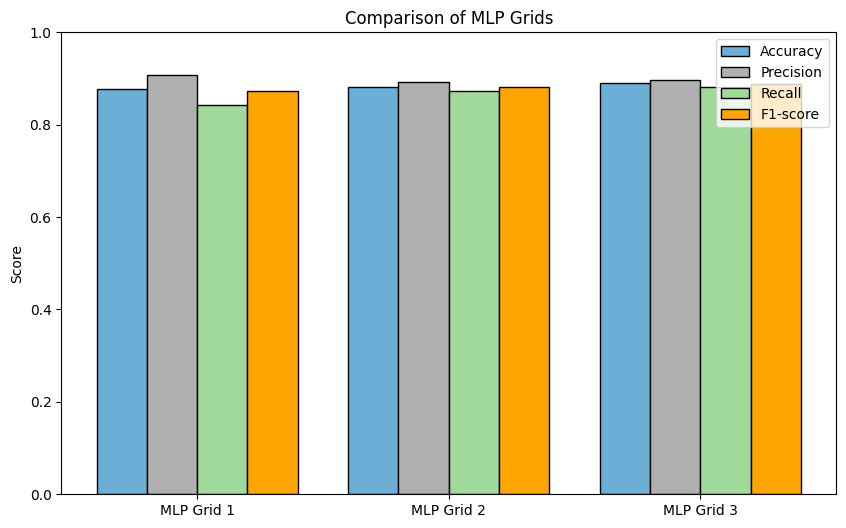

In [23]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_mlp))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_mlp[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_mlp["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of MLP Grids")
plt.legend()
plt.show()